# 1D CNN-A — Latent Space: Cluster & Visualise

Loads the trained model checkpoint, runs the encoder on every clean window to
produce a `(N_clean, LATENT_DIM)` matrix of latent vectors `Z`, clusters them
with K-Means, and visualises the structure with t-SNE and cluster centroid plots.

> **Prerequisite:** run `1dcnn_train.ipynb` first — it saves `model.pt` to
> `DATA_DIR / SYMBOL /`.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # macOS: prevents libiomp/libomp conflict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from config import Config
from data import (
    load_bars, clean_data, add_features, drop_feature_nans,
    scale_features, make_windows, filter_gap_windows,
)
from model import ConvAutoencoder, WindowDataset, load_model

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.2.2 | device: cpu


## 2. Config

In [2]:
from config import Config

cfg = Config()

# ── Override defaults here before running the rest of the notebook ────────────
# cfg.MAX_BARS       = None   # load all bars (~552k)
# cfg.EPOCHS         = 30     # full training run
# cfg.N_CLUSTERS     = 12     # try more/fewer clusters
# cfg.LATENT_DIM     = 64     # larger latent space
# cfg.N_SAMPLE       = 5_000  # render more windows in Section 9

# Expose all config fields as module-level names so every downstream cell
# can use SYMBOL, WINDOW_SIZE, LR, feature_cols, DEVICE, etc. unchanged.
globals().update(vars(cfg))

print(f"Symbol={SYMBOL}  Timeframe={TIMEFRAME}  {START_DATE} → {END_DATE}")
print("Using device:", DEVICE)

Symbol=TSLA  Timeframe=1Min  2017-01-01 → 2026-06-11
Using device: cpu


## 3. Fetch Data from Alpaca API
Calls the local `alpaca_api` FastAPI service (must be running: `uv run main.py`).
Fetches TSLA 1-minute bars and saves to both DB and CSV.

In [3]:
if FETCH_DATA:
    import httpx  # only needed when FETCH_DATA = True
    params = {
        "symbols": SYMBOL,
        "timeframe": TIMEFRAME,
        "start": START_DATE,
        "end": END_DATE,
        "save_to": "db,csv",
    }
    with httpx.Client(timeout=None) as client:
        r = client.get(f"{API_BASE}/bars", params=params)
        r.raise_for_status()
        result = r.json()
    bars = result.get("data", {}).get("bars", {}).get(SYMBOL, [])
    print(f"Fetched {len(bars)} bars for {SYMBOL}")
    print("Saved:", result.get("saved"))
else:
    print("FETCH_DATA=False — skipping. Set True in Config to re-pull.")

FETCH_DATA=False — skipping. Set True in Config to re-pull.


## 4. Load Data

In [4]:
# Load raw OHLCV bars from the CSV file.
df = load_bars(DATA_DIR, SYMBOL, TIMEFRAME, MAX_BARS)

Loaded 2,000 bars  |  2020-07-27 13:30:00+00:00 → 2020-08-10 17:55:00+00:00  |  MAX_BARS=2,000


Check for:

Duplicate timestamps
Missing timestamps (gaps)
NaNs
Infinite values
Bad OHLC relationships (high < low, etc.)

Typical checks:

In [5]:
# Remove duplicate timestamps and rows with missing values.
df = clean_data(df)

clean_data: removed 0 rows  →  2,000 remaining


## 5. Verify Time Continuity
A CNN assumes a consistent sequence.

Look for:

missing bars
duplicate bars
irregular spacing

If you're using 1-minute candles, every row should be exactly 1 minutes apart.

In [6]:
delta = df["timestamp"].diff()
dt = pd.to_timedelta(delta).dt.total_seconds()
print("Average time delta (seconds):", dt.mean())
print("Time delta distribution (seconds):")
print(dt.describe())

Average time delta (seconds): 613.0565282641321
Time delta distribution (seconds):
count      1999.000000
mean        613.056528
std        8435.323022
min          60.000000
25%          60.000000
50%          60.000000
75%         120.000000
max      235860.000000
Name: timestamp, dtype: float64


## 6. Add Features

In [7]:
# Calculate 14 technical indicator columns (EMAs, MACD, candle shape, returns, volume ratio).
df = add_features(df)

add_features: appended 14 columns  →  21 total columns


## 6. Remove Initial NaNs

Feature engineering creates NaNs.

In [8]:
# Drop the warm-up rows where EMAs and rolling means don't have enough history yet.
df = drop_feature_nans(df)

drop_feature_nans: removed 19 warm-up rows  →  1,981 remaining


## 7. Scale Features

This is critical.

CNNs train poorly on:

close = 45000
volume = 10000000
return = 0.001

all mixed together.

StandardScaler

Most common:

In [9]:
# Normalise every feature column so they all sit in a similar numeric range.
# RobustScaler uses the median and IQR — better than mean/std for financial data with outliers.
df, scaler = scale_features(df, feature_cols)

scale_features: 14 columns normalised with RobustScaler


## 8. Create Fixed-Length Windows

A CNN does not ingest an entire dataframe.

It ingests samples.

In [10]:
# Slice the time series into overlapping WINDOW_SIZE-bar windows.
# Each window is one training sample for the CNN.
X_raw = make_windows(df, feature_cols, WINDOW_SIZE)
n_features = len(feature_cols)

make_windows: 1,918 windows of shape (64 bars × 14 features)


## 11. Filter Gap Windows
A window that spans an overnight or weekend gap mixes pre-gap and post-gap bars — the CNN would learn noise, not patterns. Any window whose 64-bar span crosses a gap > 5 minutes is dropped.

In [11]:
# Remove windows that span overnight or weekend gaps.
# Such windows would teach the model noise rather than real patterns.
X_clean, valid_mask = filter_gap_windows(X_raw, df, WINDOW_SIZE)

filter_gap_windows: 128 gaps found  |  removed 1,593 windows  |  325 clean windows remain


## 13. Autoencoder Model
Encoder compresses `(batch, 14, 64)` → latent vector `(batch, LATENT_DIM)`.
Decoder reconstructs `(batch, 14, 64)` from the latent vector.
Training loss is reconstruction MSE — no labels needed.

In [12]:
# ConvAutoencoder is defined in model.py — import it at the top.
# Here we just create an instance and move it to the device (CPU or GPU).
model = ConvAutoencoder(n_features=n_features, latent_dim=LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Parameters: 141,742
ConvAutoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=1024, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4):

In [13]:
# WindowDataset is defined in model.py and imported at the top.
# It wraps a tensor so PyTorch's DataLoader can iterate it in batches.
# (No code needed here — the import at the top handles it.)

### Load Model Checkpoint

In [14]:
# Load the weights saved by 1dcnn_train.ipynb.
# load_model() builds an empty ConvAutoencoder and fills it with the saved weights.
model = load_model(DATA_DIR, SYMBOL, n_features, LATENT_DIM, DEVICE)

Model loaded ← ../../data/TSLA/model.pt  (device=cpu)


## 15. Extract Latent Vectors
Run every clean window through the encoder to get its compressed representation.

In [15]:
all_loader = DataLoader(WindowDataset(
    torch.tensor(X_clean).permute(0, 2, 1)
), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
Z_list = []
with torch.no_grad():
    for batch in all_loader:
        Z_list.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

Z = np.concatenate(Z_list)   # (N_clean, LATENT_DIM)
print(f"Latent matrix Z: {Z.shape}")

Latent matrix Z: (325, 32)


## 16. Cluster & Visualise Patterns
K-Means groups windows by latent similarity. t-SNE projects the 32-dimensional latent space to 2D so we can see the clusters. Cluster centroid plots reveal what each discovered pattern looks like.

/Volumes/My SSD/Chris Stuff/DEV/1DCNN_A/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Cluster sizes: {0: 73, 1: 57, 2: 53, 3: 31, 4: 20, 5: 14, 6: 51, 7: 26}


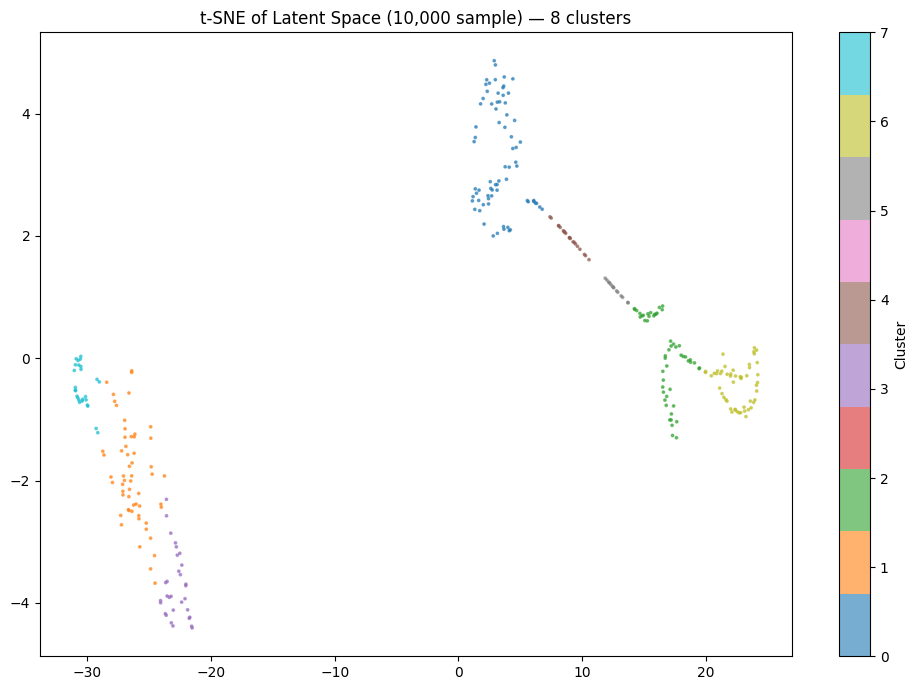

In [16]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# --- K-Means clustering ---
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z)
print("Cluster sizes:", dict(zip(*np.unique(labels, return_counts=True))))

# --- t-SNE on a subsample (full dataset is too large for t-SNE) ---
# TSNE_SAMPLE is defined in config.py
idx = np.random.choice(len(Z), size=min(TSNE_SAMPLE, len(Z)), replace=False)
Z_2d = TSNE(n_components=2, random_state=42, perplexity=50).fit_transform(Z[idx])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels[idx],
                      cmap="tab10", s=3, alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.title(f"t-SNE of Latent Space ({TSNE_SAMPLE:,} sample) — {N_CLUSTERS} clusters")
plt.tight_layout(); plt.show()

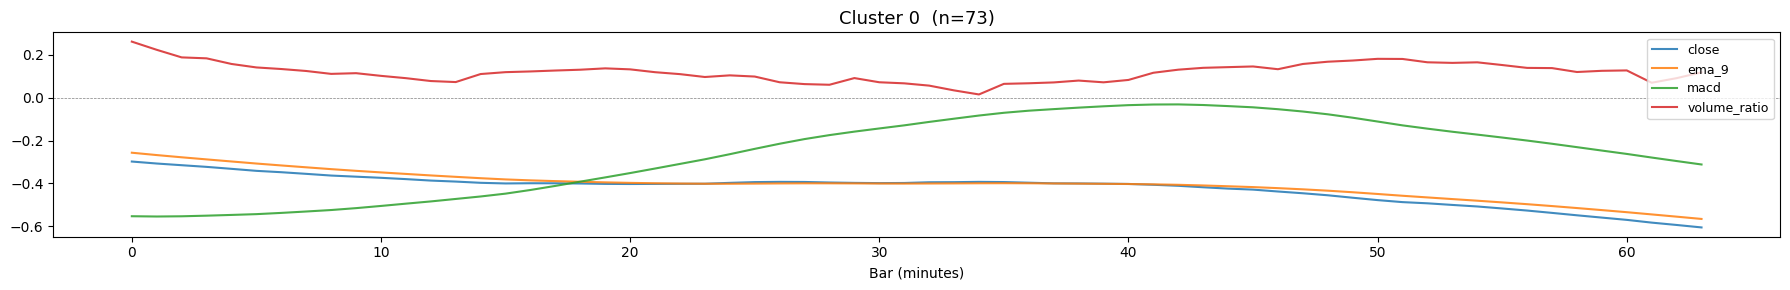

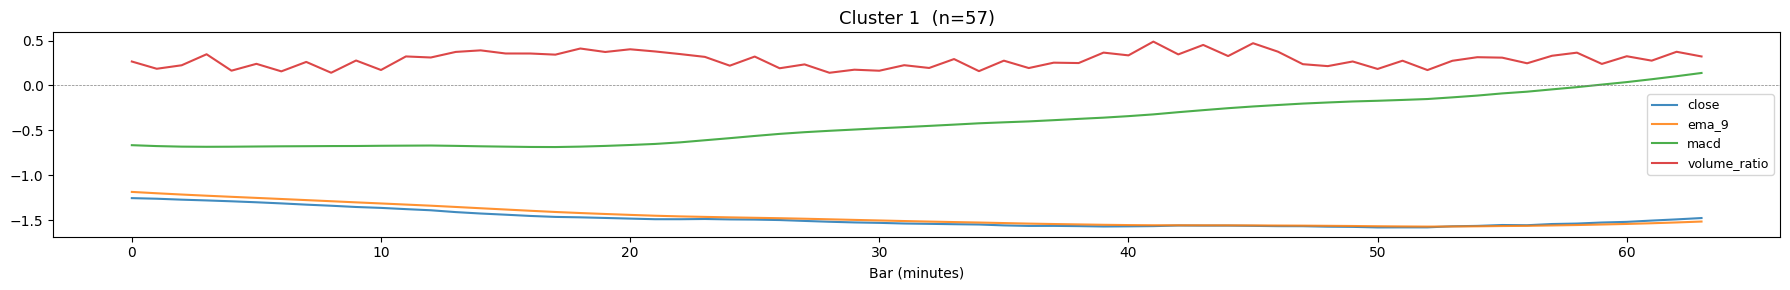

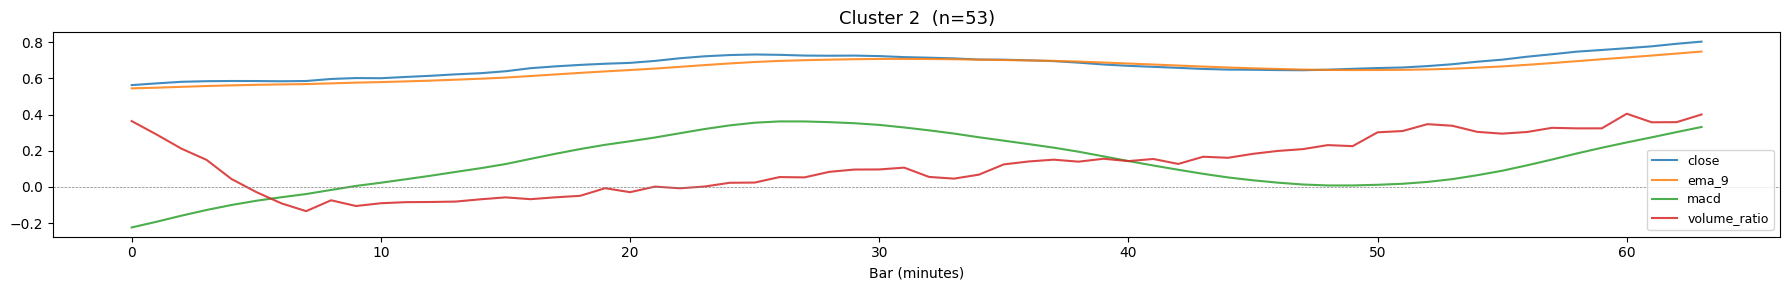

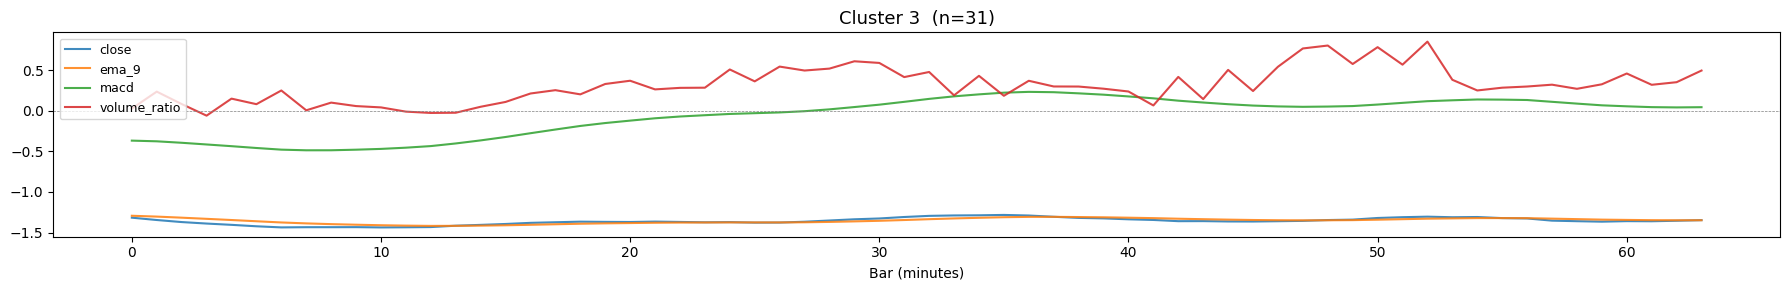

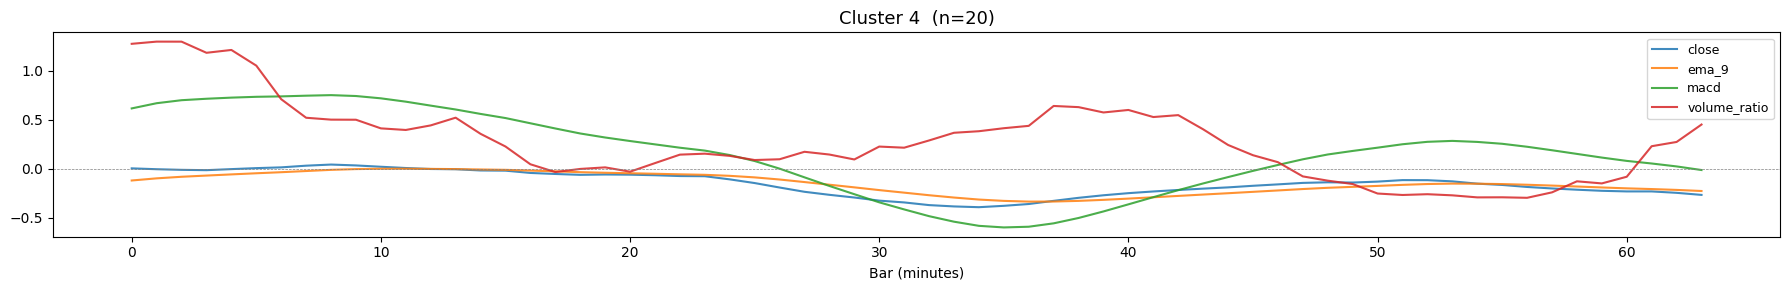

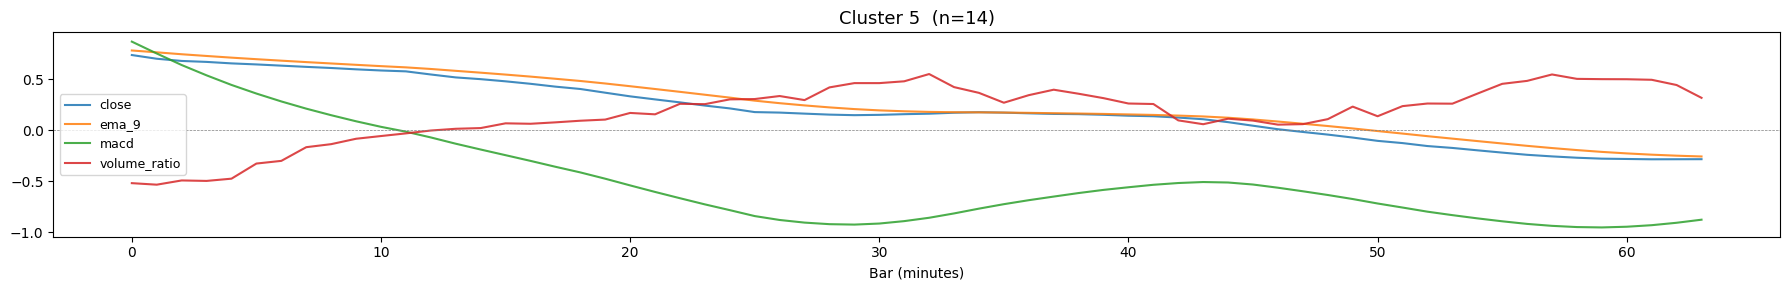

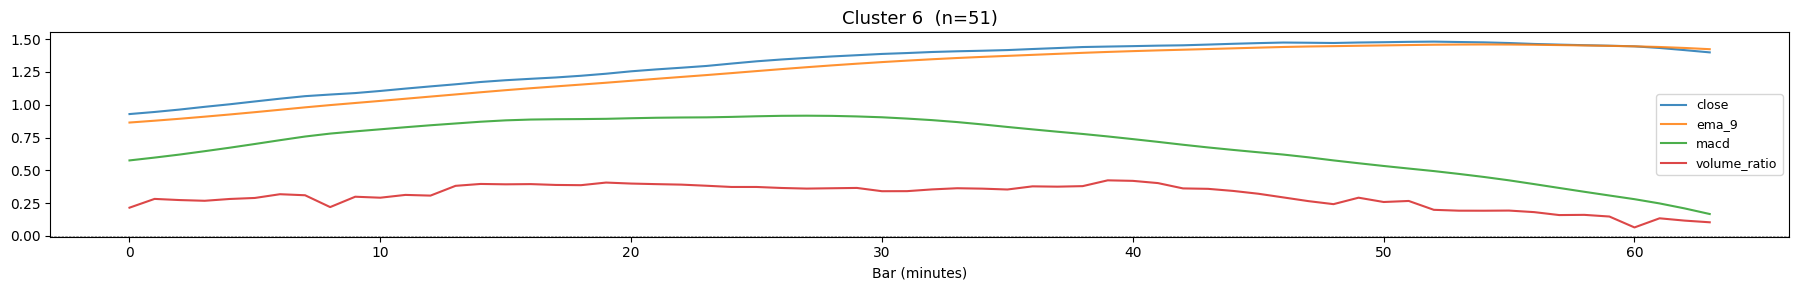

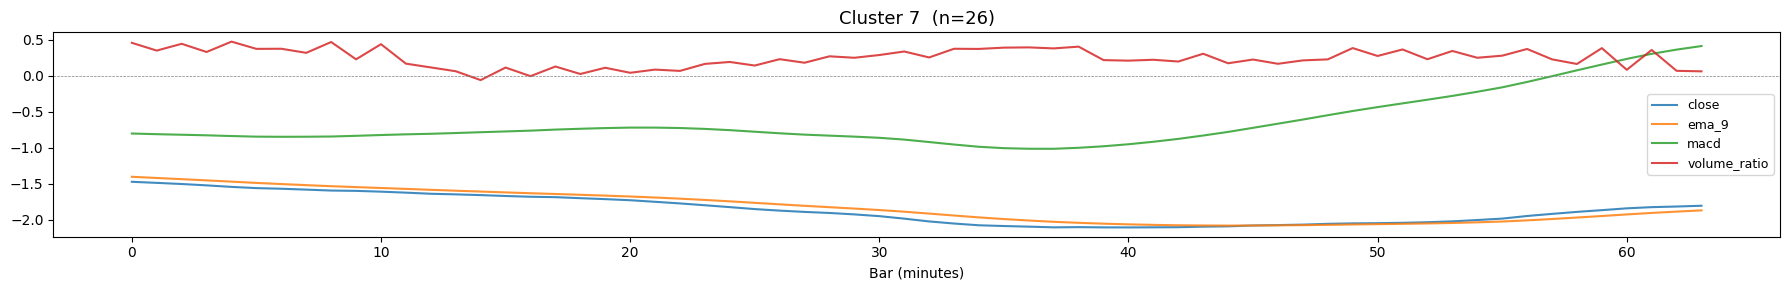

In [17]:
# --- Cluster centroid patterns (full-width, stacked) ---
# PLOT_FEATURES is defined in config.py
plot_idx = [feature_cols.index(f) for f in PLOT_FEATURES]

for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    centroid_windows = X_clean[mask][:, :, plot_idx]   # (n_in_cluster, WINDOW_SIZE, 4)
    mean_window = centroid_windows.mean(axis=0)        # (WINDOW_SIZE, 4)

    fig, ax = plt.subplots(figsize=(18, 3))
    for i, fname in enumerate(PLOT_FEATURES):
        ax.plot(mean_window[:, i], label=fname, alpha=0.85)
    ax.set_title(f"Cluster {cluster_id}  (n={mask.sum():,})", fontsize=13)
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Bar (minutes)")
    plt.tight_layout()
    plt.show()

In [18]:
from IPython.display import display, Markdown

_feature_descriptions = {
    "close":        "where {sym}'s price was, scaled so 0 = the median price over the whole dataset",
    "ema_9":        "a smoothed version of {sym}'s price over the last 9 minutes (reacts fast to moves)",
    "ema_21":       "a smoothed version of {sym}'s price over the last 21 minutes (slower trend)",
    "ema_50":       "a smoothed version of {sym}'s price over the last 50 minutes (longer-term trend)",
    "macd":         "momentum — positive = {sym} has been rising, negative = falling",
    "macd_9":       "signal line: a 9-period EMA of macd; crossovers are a classic buy/sell signal",
    "macd_hist":    "distance between macd and its signal line — growing = momentum is building",
    "volume_ratio": "how busy {sym} trading was compared to the 20-minute average (1.0 = normal)",
    "body":         "size and direction of the candle body (positive = bullish close, negative = bearish)",
    "upper_wick":   "how far price reached above the open/close during the bar",
    "lower_wick":   "how far price reached below the open/close during the bar",
    "return":       "percentage price change bar-over-bar",
    "vol_return":   "percentage volume change bar-over-bar",
    "log_return":   "log-scale price change — better for statistical analysis than raw returns",
}

_feature_lines = "\n".join(
    f"- **{f}** — {_feature_descriptions.get(f, f).format(sym=SYMBOL)}"
    for f in PLOT_FEATURES
)

_date_min = df["timestamp"].min().strftime("%b %Y")
_date_max = df["timestamp"].max().strftime("%b %Y")
_n_bars   = len(df)
_n_raw    = X_raw.shape[0]
_n_clean  = X_clean.shape[0]
_n_removed = _n_raw - _n_clean

display(Markdown(f"""
## 17. What You're Seeing

### The t-SNE Scatter Plot
Your {SYMBOL} 1-minute dataset spans {_date_min} to {_date_max} — that's **{_n_bars:,} bars**.
After slicing into overlapping {WINDOW_SIZE}-bar ({WINDOW_SIZE}-minute) windows, you have **{_n_raw:,} raw windows**.
Removing the **{_n_removed:,}** that straddle an overnight or weekend gap leaves **{_n_clean:,} clean windows**.

The autoencoder watched every one of those {SYMBOL} windows and gave each one a "fingerprint" —
{LATENT_DIM} numbers that summarise what was happening in those {WINDOW_SIZE} minutes of trading.

The problem is: {LATENT_DIM} numbers are impossible to visualise. So **t-SNE** squashes those {LATENT_DIM} numbers
down to just 2 (an x and y position on the chart) while trying to keep similar fingerprints close together.

**What the dots mean:**
- Each dot = one {WINDOW_SIZE}-minute window of {SYMBOL} trading
- Dots that are close together = windows that *felt* similar to the model
- The colour = which group (cluster) K-Means assigned it to

**What to look for:**
- Tight, well-separated blobs of colour = the model found genuinely distinct {SYMBOL} market behaviours
- A big smeared mess with no structure = the model hasn't learned much yet (try more epochs or a larger `LATENT_DIM` of {LATENT_DIM})

---

### The K-Means Clustering
K-Means is like a sorting machine. You told it: *"sort all {_n_clean:,} {SYMBOL} fingerprints into {N_CLUSTERS} piles"*
(`N_CLUSTERS = {N_CLUSTERS}`). It doesn't know anything about finance — it just puts fingerprints that are
numerically similar into the same pile.

Each pile = a **pattern type** the autoencoder found hiding in your {SYMBOL} data.
You chose {N_CLUSTERS}, but there's nothing magic about that number — try fewer or more and see if
the cluster centroid plots look more or less distinct.

---

### The Cluster Centroid Plots
These answer: *"What does a typical {SYMBOL} window in each cluster actually look like?"*

For each of the {N_CLUSTERS} clusters, we average together every {SYMBOL} window in that group and plot the result.
Think of it like averaging many photos of faces — the blurry average still shows you the general shape.

**What each line means:**
{_feature_lines}

**Example patterns you might see in {SYMBOL}:**
- A cluster where `close` and `ema_9` slope sharply upward → **strong uptrend**
- A cluster where `macd` crosses from negative to positive → **momentum reversal**
- A cluster where `volume_ratio` spikes while price is flat → **accumulation / distribution**
- A cluster where everything is flat and near zero → **dead/quiet market** (lunch hour, pre-market)

The model discovered these {N_CLUSTERS} groupings on its own — you never told it what a "trend" or "reversal" is.
"""))


## 17. What You're Seeing

### The t-SNE Scatter Plot
Your TSLA 1-minute dataset spans Jul 2020 to Aug 2020 — that's **1,981 bars**.
After slicing into overlapping 64-bar (64-minute) windows, you have **1,918 raw windows**.
Removing the **1,593** that straddle an overnight or weekend gap leaves **325 clean windows**.

The autoencoder watched every one of those TSLA windows and gave each one a "fingerprint" —
32 numbers that summarise what was happening in those 64 minutes of trading.

The problem is: 32 numbers are impossible to visualise. So **t-SNE** squashes those 32 numbers
down to just 2 (an x and y position on the chart) while trying to keep similar fingerprints close together.

**What the dots mean:**
- Each dot = one 64-minute window of TSLA trading
- Dots that are close together = windows that *felt* similar to the model
- The colour = which group (cluster) K-Means assigned it to

**What to look for:**
- Tight, well-separated blobs of colour = the model found genuinely distinct TSLA market behaviours
- A big smeared mess with no structure = the model hasn't learned much yet (try more epochs or a larger `LATENT_DIM` of 32)

---

### The K-Means Clustering
K-Means is like a sorting machine. You told it: *"sort all 325 TSLA fingerprints into 8 piles"*
(`N_CLUSTERS = 8`). It doesn't know anything about finance — it just puts fingerprints that are
numerically similar into the same pile.

Each pile = a **pattern type** the autoencoder found hiding in your TSLA data.
You chose 8, but there's nothing magic about that number — try fewer or more and see if
the cluster centroid plots look more or less distinct.

---

### The Cluster Centroid Plots
These answer: *"What does a typical TSLA window in each cluster actually look like?"*

For each of the 8 clusters, we average together every TSLA window in that group and plot the result.
Think of it like averaging many photos of faces — the blurry average still shows you the general shape.

**What each line means:**
- **close** — where TSLA's price was, scaled so 0 = the median price over the whole dataset
- **ema_9** — a smoothed version of TSLA's price over the last 9 minutes (reacts fast to moves)
- **macd** — momentum — positive = TSLA has been rising, negative = falling
- **volume_ratio** — how busy TSLA trading was compared to the 20-minute average (1.0 = normal)

**Example patterns you might see in TSLA:**
- A cluster where `close` and `ema_9` slope sharply upward → **strong uptrend**
- A cluster where `macd` crosses from negative to positive → **momentum reversal**
- A cluster where `volume_ratio` spikes while price is flat → **accumulation / distribution**
- A cluster where everything is flat and near zero → **dead/quiet market** (lunch hour, pre-market)

The model discovered these 8 groupings on its own — you never told it what a "trend" or "reversal" is.
